# Phase B — detect-then-classify pipeline demo

Sanity-check the dashcam-sign-detector pipeline end to end:

1. The FastAI ResNet classifier (Phase A artifact) is wired correctly via
   `FastAIClassifier` and returns sensible predictions on real GTSRB test crops.
2. The torchvision detector loads, runs, and filters to the expected COCO classes.
3. `DetectionClassificationPipeline` composes the two stages correctly.

**Known limitation of the v1 detector:** it is COCO-pretrained and only knows
`stop sign` and `traffic light` out of its 91 classes, which covers almost none
of the 43 European GTSRB classes. Running the detector directly on GTSRB crops
will return zero detections — that is expected, not a bug. The v2 upgrade is to
fine-tune the detector on GTSDB (German Traffic Sign Detection Benchmark), which
has full-scene bounding boxes. For now we verify the detector on a separate
street-scene image and exercise the crop→classify path with a forced bbox.

In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

from dashcam_sign_detector.classifier.config import ClassifierConfig
from dashcam_sign_detector.detector.detect import Detection, SignDetector, list_available_models
from dashcam_sign_detector.pipeline import (
    DetectionClassificationPipeline,
    FastAIClassifier,
    build_default_pipeline,
)

cfg = ClassifierConfig()
print("Classifier path:", cfg.model_path)
print("Classifier exists:", cfg.model_path.exists())
print("Available detectors:", list_available_models())

Classifier path: /home/riley/roest1/github/dashcam-sign-detector/models/classifier_data0_resnet34.pkl
Classifier exists: True
Available detectors: ['fasterrcnn_mobilenet_v3_large_fpn', 'fasterrcnn_resnet50_fpn_v2', 'fcos_resnet50_fpn', 'retinanet_resnet50_fpn_v2', 'ssdlite320_mobilenet_v3_large']


## Part 1 — classifier wiring check

Load the Phase A learner through the `FastAIClassifier` wrapper and batch-predict
a handful of GTSRB test crops. The test split directory is organised as
`data{N}test/<class_id>/image_*.png`, so the parent directory of each file is the
ground-truth label.

In [2]:
classifier = FastAIClassifier(cfg.model_path)
print("Vocab size:", len(classifier.vocab))

test_root = cfg.images_dir / cfg.test_split
assert test_root.exists(), f"Processed test split not found at {test_root}"

all_test = list(test_root.rglob("*.png"))
random.seed(42)
sample_paths = random.sample(all_test, k=16)

pil_crops = [Image.open(p).convert("RGB") for p in sample_paths]
true_labels = [p.parent.name for p in sample_paths]

preds = classifier.predict_batch(pil_crops)
pred_labels = [classifier.vocab[idx] for idx, _ in preds]
pred_confs = [conf for _, conf in preds]

correct = sum(1 for t, p in zip(true_labels, pred_labels) if t == p)
print(f"Correct on 16 random test crops: {correct}/16")

Vocab size: 43


/home/riley/roest1/github/dashcam-sign-detector/.venv/lib/python3.13/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


Correct on 16 random test crops: 16/16


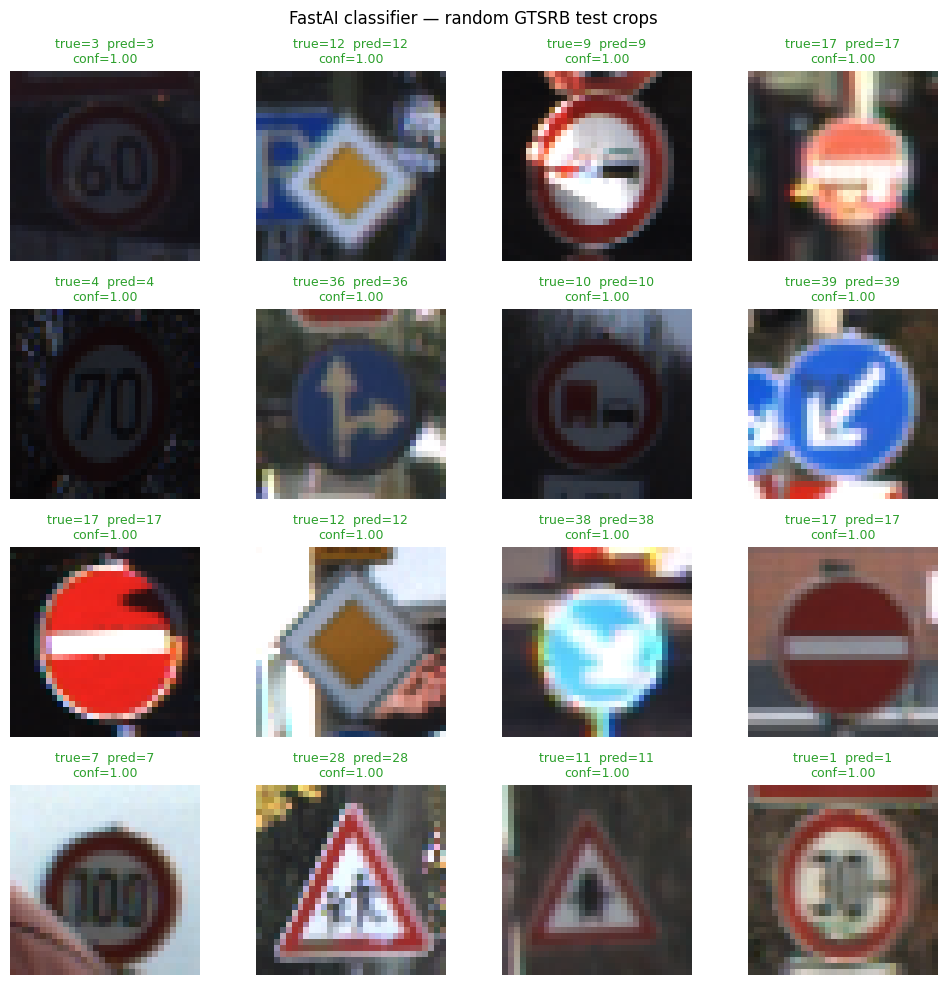

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for ax, crop, truth, pred, conf in zip(
    axes.flat, pil_crops, true_labels, pred_labels, pred_confs
):
    ax.imshow(crop)
    colour = "tab:green" if truth == pred else "tab:red"
    ax.set_title(f"true={truth}  pred={pred}\nconf={conf:.2f}", color=colour, fontsize=9)
    ax.axis("off")
plt.suptitle("FastAI classifier — random GTSRB test crops", fontsize=12)
plt.tight_layout()
plt.show()

## Part 2 — detector on a real scene

Drop a dashcam frame or street-scene JPG at `notebooks/fixtures/scene.jpg` to
exercise the detector. If the fixture is missing, the cell falls back to a
random-noise frame, which is a useful liveness check (should return zero
detections and not crash).

In [4]:
scene_path = Path("fixtures/scene.jpg")
if scene_path.exists():
    scene_rgb = np.asarray(Image.open(scene_path).convert("RGB"))
    source = f"fixture: {scene_path}"
else:
    rng = np.random.default_rng(seed=0)
    scene_rgb = rng.integers(0, 256, size=(480, 640, 3), dtype=np.uint8)
    source = "synthetic random-noise frame (no fixture supplied)"

print("Scene source:", source)
print("Scene shape:", scene_rgb.shape)

detector = SignDetector(model_name="fasterrcnn_resnet50_fpn_v2", score_threshold=0.5)
detections = detector.detect(scene_rgb)
print(f"Detections: {len(detections)}")
for d in detections:
    print(" -", d)

Scene source: synthetic random-noise frame (no fixture supplied)
Scene shape: (480, 640, 3)


Detections: 0


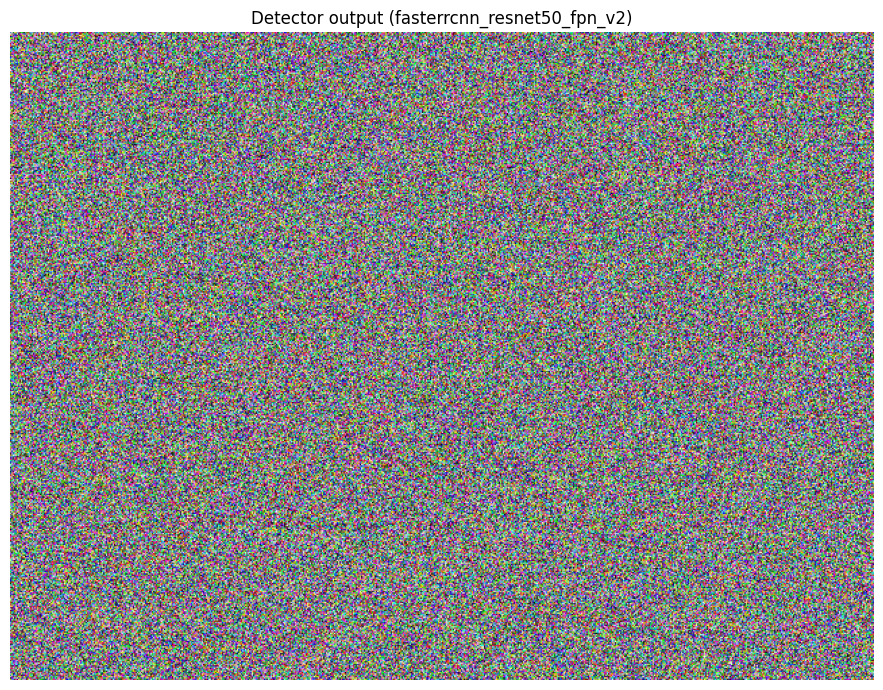

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(scene_rgb)
for det in detections:
    x1, y1, x2, y2 = det.bbox
    ax.add_patch(
        plt.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor="lime",
            facecolor="none",
        )
    )
    ax.text(
        x1,
        y1 - 5,
        f"{det.label} {det.score:.2f}",
        color="black",
        backgroundcolor="lime",
        fontsize=9,
    )
ax.set_title(f"Detector output ({detector.model_name})")
ax.axis("off")
plt.tight_layout()
plt.show()

## Part 3 — full pipeline with a forced-bbox detector

Since the COCO-pretrained detector will not find anything on the pre-cropped
GTSRB test images, we compose the pipeline with a tiny in-notebook detector
that always returns a full-frame bbox. This exercises the detect→crop→classify
plumbing end to end and lets us confirm that `DetectionClassificationPipeline`
yields `PipelineResult` records with the classifier's actual label.

In [6]:
class FullFrameDetector:
    """Test-only detector: emits a single full-frame bbox tagged as 'stop sign'."""

    def detect(self, image):
        h, w = image.shape[:2]
        return [Detection(bbox=(0, 0, w, h), label="stop sign", score=0.95)]

pipe = DetectionClassificationPipeline(detector=FullFrameDetector(), classifier=classifier)

demo_paths = random.sample(all_test, k=4)
for p in demo_paths:
    arr = np.asarray(Image.open(p).convert("RGB"))
    results = pipe.run(arr)
    truth = p.parent.name
    for r in results:
        ok = "OK  " if r.classifier_class == truth else "MISS"
        print(
            f"{ok} file={p.name:>16}  true={truth:>3}  "
            f"pred={r.classifier_class:>3}  conf={r.classifier_confidence:.3f}  "
            f"det={r.detector_class}@{r.detector_score:.2f}"
        )

MISS file=  image_3518.png  true= 30  pred= 28  conf=0.626  det=stop sign@0.95


OK   file=  image_9060.png  true= 18  pred= 18  conf=1.000  det=stop sign@0.95


OK   file=  image_4532.png  true= 11  pred= 11  conf=1.000  det=stop sign@0.95


OK   file=  image_8629.png  true=  9  pred=  9  conf=1.000  det=stop sign@0.95


## Part 4 — realistic pipeline factory

`build_default_pipeline()` is the entry point the realtime loop (Phase C) and
the Gradio app (Phase E) will use. It wires the torchvision detector in front of
the FastAI classifier with sensible defaults. Swap the detector backbone by
passing `detector_model=` — use `ssdlite320_mobilenet_v3_large` when CPU latency
matters (HF Spaces free tier), or `fasterrcnn_resnet50_fpn_v2` when accuracy
matters (local GPU).

In [7]:
default_pipe = build_default_pipeline(
    detector_model="ssdlite320_mobilenet_v3_large",
    score_threshold=0.3,
)
print("Detector:", default_pipe.detector.model_name)
print("Detector device:", default_pipe.detector.device)
print("Classifier vocab size:", len(default_pipe.classifier.vocab))

Detector: ssdlite320_mobilenet_v3_large
Detector device: cuda
Classifier vocab size: 43


/home/riley/roest1/github/dashcam-sign-detector/.venv/lib/python3.13/site-packages/fastai/learner.py:455: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


## Next steps

- **Phase C**: OpenCV real-time loop reading webcam/video/RTSP, feeding each frame
  through `build_default_pipeline().run()` and drawing the annotated bboxes back.
- **Phase D**: record or source a dashcam clip, run the pipeline, produce the
  README hero GIF.
- **v2 upgrade**: fine-tune the detector on GTSDB so it actually sees the 43
  GTSRB classes instead of just the two COCO ones. Until then, the README must
  document the COCO-pretrained limitation honestly.